# 04 - Demo

Run prediction on sample images for the final presentation.

This notebook intentionally uses CPU inference to avoid GPU memory conflicts during live demos. Training and evaluation scripts can still use the GPU.


In [1]:
import sys
from pathlib import Path

print('Notebook Python:', sys.executable)
current = Path.cwd().resolve()
expected_python = None
for path in [current, *current.parents]:
    candidate = path / '.venv' / 'bin' / 'python'
    if candidate.exists():
        expected_python = candidate
        break

if expected_python and Path(sys.executable).resolve() != expected_python.resolve():
    print('WARNING: This notebook is not using the project .venv kernel.')
    print('Expected:', expected_python)
    print('In VS Code, select kernel: KidMood (.venv)')
else:
    print('Kernel check passed.')


Notebook Python: /home/daddy/Desktop/_DEV/_SCHOOL/ITAI-1378_COMP-VISION/KidMood-Final-Project/.venv/bin/python
Kernel check passed.


In [2]:
from pathlib import Path
import os
import sys

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
# CPU inference is more reliable for live demos and avoids GPU memory conflicts.
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for path in [current, *current.parents]:
        if (path / 'src' / 'data_processing.py').exists():
            return path
    raise FileNotFoundError('Could not find project root containing src/data_processing.py')

PROJECT_ROOT = find_project_root()
src_path = PROJECT_ROOT / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Visible GPUs for this demo notebook:", tf.config.list_physical_devices("GPU"))

from PIL import Image

from utils import CLASS_NAMES, load_single_image_for_inference, timed_prediction


I0000 00:00:1778279776.184247   40785 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778279776.211777   40785 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778279776.797355   40785 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
Built with CUDA: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
model_path = PROJECT_ROOT / 'models' / 'trained' / 'kidmood_mobilenetv2.keras'
sample_dir = PROJECT_ROOT / 'data' / 'sample'

if not model_path.exists():
    raise FileNotFoundError(f'Train model first. Missing: {model_path}')

model = tf.keras.models.load_model(model_path)
print('Loaded model:', model_path)
print('Visible GPUs for this demo notebook:', tf.config.list_physical_devices('GPU'))


I0000 00:00:1778279777.489395   40785 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13016 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


Loaded model: /home/daddy/Desktop/_DEV/_SCHOOL/ITAI-1378_COMP-VISION/KidMood-Final-Project/models/trained/kidmood_mobilenetv2.keras
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Sample images: ['angry-boy.jpg', 'angry_demo.jpg', 'fear_demo.jpg', 'happy_demo.jpg', 'sad-boy.jpg', 'sad-girl.jpg', 'sad_demo.jpg']


I0000 00:00:1778279778.977157   40981 service.cc:153] XLA service 0x7240b805ae90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778279778.977169   40981 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4070 Ti SUPER, Compute Capability 8.9 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1778279778.992951   40981 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778279779.216545   40981 cuda_dnn.cc:461] Loaded cuDNN version 92101
E0000 00:00:1778279783.008898   40981 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1778279784.755752   40981 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


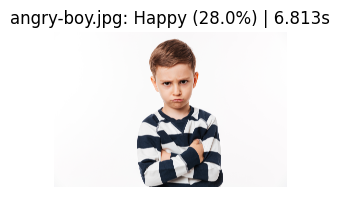

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


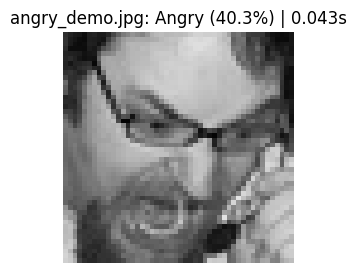

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


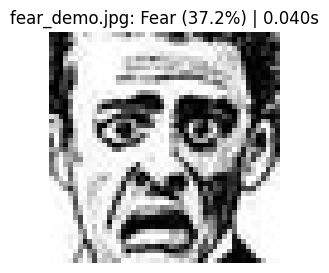

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


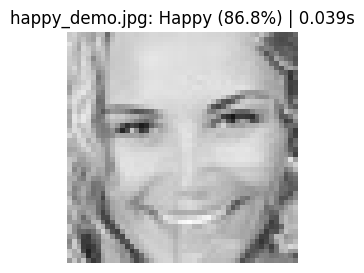

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


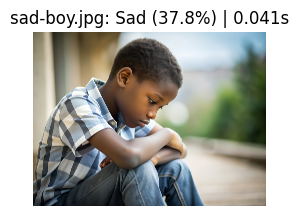

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


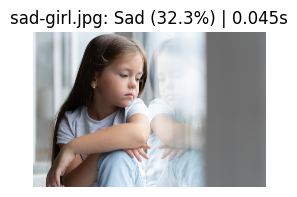

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


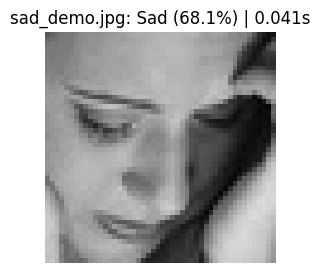

In [4]:
image_files = sorted(list(sample_dir.glob('*.png')) + list(sample_dir.glob('*.jpg')) + list(sample_dir.glob('*.jpeg')))
print('Sample images:', [path.name for path in image_files])

if not image_files:
    raise FileNotFoundError('Add demo images from data/raw/test/{angry,fear,happy,sad} to data/sample.')

for img_path in image_files:
    batch = load_single_image_for_inference(img_path)
    probs, elapsed = timed_prediction(model, batch)
    pred_idx = int(probs[0].argmax())
    label = CLASS_NAMES[pred_idx]
    confidence = float(probs[0][pred_idx])

    plt.figure(figsize=(3, 3))
    plt.imshow(Image.open(img_path).convert('RGB'))
    plt.axis('off')
    plt.title(f'{img_path.name}: {label} ({confidence:.1%}) | {elapsed:.3f}s')
    plt.show()
